In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle, os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Use GPU if available, else CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

Using device: cpu
PyTorch version: 2.8.0+cpu


In [4]:
# Load the .npy files saved in Phase 1
X_train = np.load('../data/X_train.npy')
y_train = np.load('../data/y_train.npy')

with open('../models/feature_cols.pkl', 'rb') as f:
    feature_cols = pickle.load(f)

print(f"X_train : {X_train.shape}  → (samples, window, features)")
print(f"y_train : {y_train.shape}")
print(f"Features: {feature_cols}")

X_train : (17631, 30, 8)  → (samples, window, features)
y_train : (17631,)
Features: ['sensor_11', 'sensor_4', 'sensor_12', 'sensor_7', 'sensor_21', 'sensor_20', 'sensor_17', 'sensor_2']


In [5]:
# Convert numpy arrays → PyTorch tensors
X_tensor = torch.tensor(X_train, dtype=torch.float32)
y_tensor = torch.tensor(y_train, dtype=torch.float32)

dataset = TensorDataset(X_tensor, y_tensor)

# 80% train, 20% validation split
train_size = int(0.8 * len(dataset))
val_size   = len(dataset) - train_size
train_set, val_set = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=64, shuffle=False)

print(f"Train batches : {len(train_loader)}  ({train_size} samples)")
print(f"Val batches   : {len(val_loader)}  ({val_size} samples)")
print(f"Batch shape   : {next(iter(train_loader))[0].shape}")

Train batches : 221  (14104 samples)
Val batches   : 56  (3527 samples)
Batch shape   : torch.Size([64, 30, 8])


In [6]:
class RULPredictor(nn.Module):
    def __init__(self, input_size, hidden_size=64,
                 num_layers=2, dropout=0.2):
        super().__init__()
        # LSTM layer — reads sequences, remembers patterns over time
        self.lstm = nn.LSTM(
            input_size  = input_size,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            batch_first = True,
            dropout     = dropout
        )
        # Fully connected layers to produce final RUL prediction
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        # x shape: (batch, 30, 8)
        lstm_out, _ = self.lstm(x)
        # Take only the last timestep output
        last_out = lstm_out[:, -1, :]
        return self.fc(last_out).squeeze(1)

# Instantiate model
INPUT_SIZE = X_train.shape[2]  # = 8 features
model = RULPredictor(input_size=INPUT_SIZE).to(device)

# Print architecture summary
print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal trainable parameters: {total_params:,}")

RULPredictor(
  (lstm): LSTM(8, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=1, bias=True)
  )
)

Total trainable parameters: 54,337


In [8]:
# Reduce learning rate if val loss stops improving
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimiser, mode='min', factor=0.5, patience=5
)

print("Loss     : MSELoss")
print("Optimiser: Adam (lr=0.001)")
print("Scheduler: ReduceLROnPlateau (patience=5)")

Loss     : MSELoss
Optimiser: Adam (lr=0.001)
Scheduler: ReduceLROnPlateau (patience=5)


In [9]:
EPOCHS = 30
train_losses, val_losses = [], []
best_val_loss = float('inf')

print(f"Training for {EPOCHS} epochs...\n")

for epoch in range(EPOCHS):

    # ── Train ──────────────────────────────────────
    model.train()
    batch_losses = []
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimiser.zero_grad()
        preds = model(X_batch)
        loss  = criterion(preds, y_batch)
        loss.backward()
        optimiser.step()
        batch_losses.append(loss.item())

    train_loss = np.mean(batch_losses)
    train_losses.append(train_loss)

    # ── Validate ───────────────────────────────────
    model.eval()
    val_batch_losses = []
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            preds   = model(X_batch)
            val_batch_losses.append(criterion(preds, y_batch).item())

    val_loss = np.mean(val_batch_losses)
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), '../models/lstm_best.pt')
        saved = "✅ saved"
    else:
        saved = ""

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:02d}/{EPOCHS} │ "
              f"Train Loss: {train_loss:.2f} │ "
              f"Val Loss: {val_loss:.2f}  {saved}")

print(f"\n✅ Training complete! Best val loss: {best_val_loss:.2f}")

Training for 30 epochs...

Epoch 01/30 │ Train Loss: 5477.52 │ Val Loss: 2265.08  ✅ saved
Epoch 05/30 │ Train Loss: 1885.77 │ Val Loss: 1738.09  
Epoch 10/30 │ Train Loss: 1904.75 │ Val Loss: 1734.31  
Epoch 15/30 │ Train Loss: 533.87 │ Val Loss: 322.69  
Epoch 20/30 │ Train Loss: 429.89 │ Val Loss: 313.13  
Epoch 25/30 │ Train Loss: 414.72 │ Val Loss: 243.45  
Epoch 30/30 │ Train Loss: 403.44 │ Val Loss: 238.24  

✅ Training complete! Best val loss: 236.52


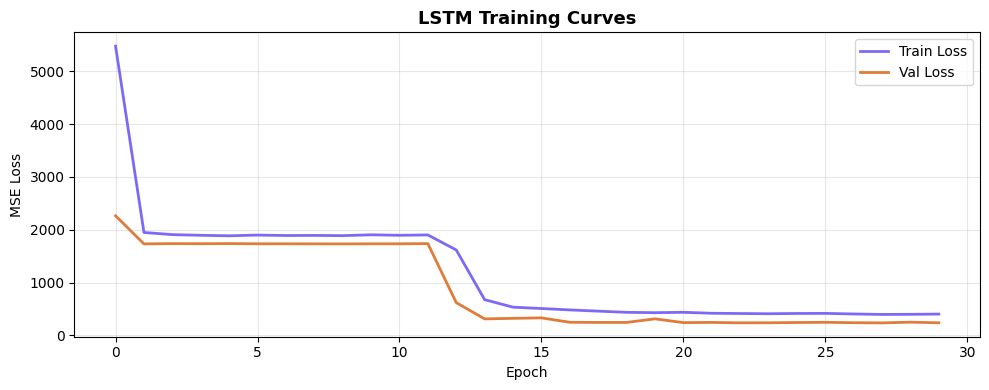

Saved → data/plot4_training_curves.png


In [10]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(train_losses, label='Train Loss', color='#7c6af7', linewidth=2)
ax.plot(val_losses,   label='Val Loss',   color='#e07b39', linewidth=2)
ax.set_title('LSTM Training Curves', fontsize=13, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../data/plot4_training_curves.png', dpi=120)
plt.show()
print("Saved → data/plot4_training_curves.png")

In [11]:
# Load the best saved model
model.load_state_dict(torch.load('../models/lstm_best.pt',
                                  map_location=device))
model.eval()

all_preds, all_true = [], []
with torch.no_grad():
    for X_batch, y_batch in val_loader:
        preds = model(X_batch.to(device))
        all_preds.extend(preds.cpu().numpy())
        all_true.extend(y_batch.numpy())

all_preds = np.array(all_preds)
all_true  = np.array(all_true)

rmse = np.sqrt(mean_squared_error(all_true, all_preds))
mae  = mean_absolute_error(all_true, all_preds)

print(f"RMSE : {rmse:.2f} cycles")
print(f"MAE  : {mae:.2f} cycles")
print(f"\nInterpretation: on average the model's RUL")
print(f"prediction is off by ~{mae:.0f} cycles")

RMSE : 15.28 cycles
MAE  : 11.78 cycles

Interpretation: on average the model's RUL
prediction is off by ~12 cycles


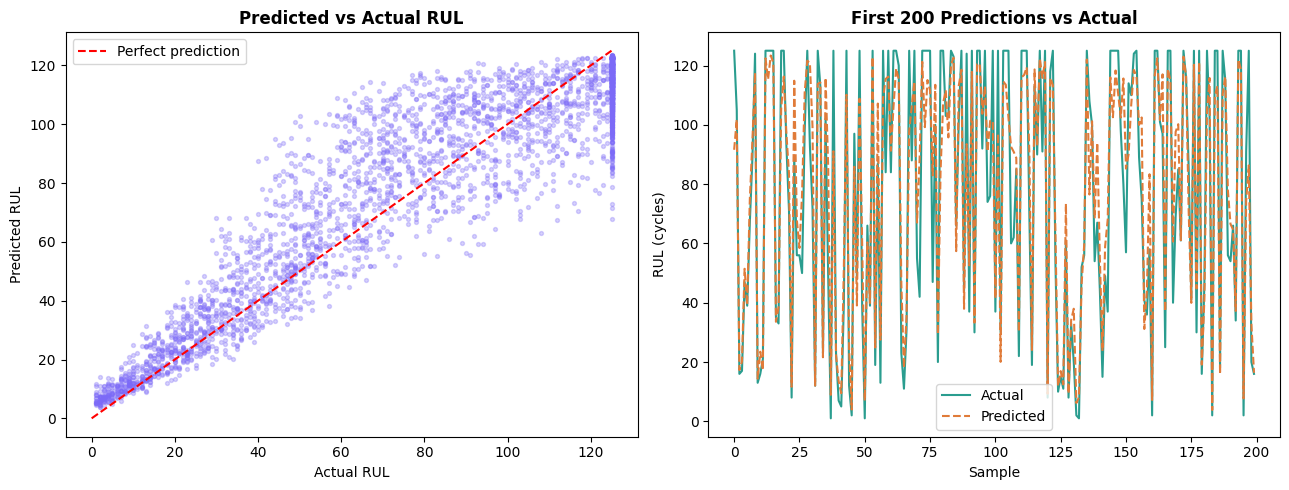

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter: predicted vs actual
axes[0].scatter(all_true, all_preds, alpha=0.3,
               color='#7c6af7', s=8)
axes[0].plot([0, 125], [0, 125], 'r--', linewidth=1.5,
             label='Perfect prediction')
axes[0].set_xlabel('Actual RUL')
axes[0].set_ylabel('Predicted RUL')
axes[0].set_title('Predicted vs Actual RUL', fontweight='bold')
axes[0].legend()

# First 200 predictions timeline
axes[1].plot(all_true[:200],  label='Actual',
             color='#2a9d8f', linewidth=1.5)
axes[1].plot(all_preds[:200], label='Predicted',
             color='#e07b39', linewidth=1.5, linestyle='--')
axes[1].set_xlabel('Sample')
axes[1].set_ylabel('RUL (cycles)')
axes[1].set_title('First 200 Predictions vs Actual', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/plot5_predictions.png', dpi=120)
plt.show()

In [13]:
# Convert raw RUL prediction into actionable business alert
def get_risk_level(predicted_rul):
    """
    Translates RUL number into a maintenance decision.
    This is the business logic layer of the project.
    """
    if predicted_rul <= 15:
        return "🔴 CRITICAL", "Schedule immediate maintenance"
    elif predicted_rul <= 40:
        return "🟡 WARNING",  "Plan maintenance within 1 week"
    elif predicted_rul <= 75:
        return "🟢 MONITOR",  "Check again at next service interval"
    else:
        return "✅ HEALTHY",  "No action required"

# Demo on 5 sample predictions
print("Sample Predictions\n" + "─"*55)
print(f"{'Engine':10} {'Actual RUL':14} {'Predicted':12} {'Risk':12} Action")
print("─"*70)

sample_idx = [0, 50, 100, 200, 400]
for i, idx in enumerate(sample_idx):
    actual    = all_true[idx]
    predicted = all_preds[idx]
    risk, action = get_risk_level(predicted)
    print(f"Engine {i+1:4}  {actual:14.1f} {predicted:12.1f} {risk:14} {action}")

Sample Predictions
───────────────────────────────────────────────────────
Engine     Actual RUL     Predicted    Risk         Action
──────────────────────────────────────────────────────────────────────
Engine    1           125.0         91.6 ✅ HEALTHY      No action required
Engine    2             1.0          6.9 🔴 CRITICAL     Schedule immediate maintenance
Engine    3            37.0         41.5 🟢 MONITOR      Check again at next service interval
Engine    4            15.0         15.4 🟡 WARNING      Plan maintenance within 1 week
Engine    5            23.0         21.7 🟡 WARNING      Plan maintenance within 1 week


In [14]:
import json

# Save model metrics
metrics = {
    'rmse'          : float(round(rmse, 2)),
    'mae'           : float(round(mae,  2)),
    'best_val_loss' : float(round(best_val_loss, 2)),
    'epochs'        : EPOCHS,
    'window_size'   : 30,
    'features'      : feature_cols,
}

with open('../models/lstm_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

print("✅ Phase 2 complete! Saved:")
print("   models/lstm_best.pt       → trained LSTM weights")
print("   models/lstm_metrics.json  → RMSE, MAE, config")
print("   data/plot4_training_curves.png")
print("   data/plot5_predictions.png")
print(f"\n📊 Final metrics:")
print(f"   RMSE : {rmse:.2f} cycles")
print(f"   MAE  : {mae:.2f} cycles")
print(f"\n🚀 Ready for Phase 3 — NLP on maintenance logs!")

✅ Phase 2 complete! Saved:
   models/lstm_best.pt       → trained LSTM weights
   models/lstm_metrics.json  → RMSE, MAE, config
   data/plot4_training_curves.png
   data/plot5_predictions.png

📊 Final metrics:
   RMSE : 15.28 cycles
   MAE  : 11.78 cycles

🚀 Ready for Phase 3 — NLP on maintenance logs!
